# Threshold Analysis of Anomaly Scores

We test and compare the results given by five threshold methods on the anomaly scores of the three models (Transformer+OC-SVM, PRAE, PNN) on the held-out Test Day (Day 25).

**Threshold methods:**
| Method | Description |
|--------|-------------|
| Statistical | mean + 3σ |
| POT | Peak Over Threshold (EVT) |
| DSPOT | Drift Streaming POT |
| Rolling FDR | Benjamini-Hochberg on a rolling window |

For each model × threshold combination we report the anomaly count and rate, broken down by time period.

We compare these results with the results obtained by the original methods in the literature when applicable (OC-SVM for the Transformer, spoofing gain for the PNN). Otherwise, we use the reconstruction error from the Transformer and the PRAE, and the NLL from the PNN as the baselines for the threshold methods.

In [ ]:
import os, sys, math, logging, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences, load_processed
from detection.models.hybrid import TransformerOCSVM
from detection.models.pnn import PNN
from detection.models.prae import PRAE
from detection.models.transformer import BottleneckTransformer
from detection.thresholds.pot import PeakOverThreshold
from detection.thresholds.dspot import DriftStreamingPeakOverThreshold
from detection.thresholds.rfdr import RollingFalseDiscoveryRate

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## Configuration & Data Loading

In [ ]:
DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results")
MODEL_TYPES = ["transformer_ocsvm", "pnn", "prae"]
SEQ_LENGTH = 25
BATCH_SIZE = 64

# LOB columns present in processed files (not features)
LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [("bid","price"),("bid","volume"),("ask","price"),("ask","volume")]
]

PERIODS = {
    "1st_hour":       (9.0,  10.0),
    "rest_of_morning":(10.0, 12.0),
    "afternoon":      (12.0, 15.5),
    "american_open":  (15.5, 17.5),
}

# Threshold configurations
THRESHOLD_CONFIGS = {
    "Percentile_95": {"method": "percentile", "q": 0.95},
    "Statistical":   {"method": "statistical", "k": 3.0},
    "POT":           {"method": "pot", "risk": 1e-4, "init_level": 0.98, "num_candidates": 10},
    "DSPOT":         {"method": "dspot", "risk": 1e-4, "init_level": 0.98, "num_candidates": 10, "depth": 50},
    "Rolling_FDR":   {"method": "rfdr", "window_size": 500, "alpha": 0.05},
}

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
# Use the first held-out test file (last 3 of 2015)
TEST_FILE = FILES[22]
print(f"Test file: {os.path.basename(TEST_FILE)}")
print(f"Thresholds to test: {list(THRESHOLD_CONFIGS.keys())}")

## Compute Anomaly Scores for All Models

In [ ]:
df_test, features_test = load_processed(TEST_FILE, "xltime", LOB_COLUMNS)
features_test = features_test.iloc[:10000]
df_test = df_test.iloc[:len(features_test)].reset_index(drop=True)

time_frac = df_test["xltime"].values - np.floor(df_test["xltime"].values)
time_frac_seq = time_frac[:len(features_test)]
period_labels = np.full(len(time_frac_seq), "unknown", dtype=object)
for name, (o, c) in PERIODS.items():
    mask = (time_frac_seq >= o / 24.0) & (time_frac_seq < c / 24.0)
    period_labels[mask] = name

period_labels_seq = period_labels[SEQ_LENGTH: SEQ_LENGTH + len(features_test) - SEQ_LENGTH]

all_scores = {}

for model_type in MODEL_TYPES:
    feat_path = os.path.join(RESULTS_DIR, f"{model_type}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as f:
            feat_names = [l.strip() for l in f if l.strip()]
    else:
        feat_names = features_test.columns.tolist()

    feat_df = features_test.copy()
    for col in feat_names:
        if col not in feat_df.columns:
            feat_df[col] = 0.0
    feat_df = feat_df[feat_names]

    scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
    scaler = joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()
    scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
    sequences = create_sequences(scaled, SEQ_LENGTH)
    num_features = len(feat_names)

    weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")

    if model_type == "transformer_ocsvm":
        transformer = BottleneckTransformer(
            num_features=num_features, model_dim=128, num_heads=8,
            num_layers=6, representation_dim=128, sequence_length=SEQ_LENGTH,
            dim_feedforward=512)
        transformer.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        transformer.eval().to(DEVICE)
        ocsvm_path = weights_path.replace("_weights.pth", "_detector.pth")
        x_t = torch.tensor(sequences, dtype=torch.float32)
        ds = TensorDataset(x_t, x_t)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
        if os.path.exists(ocsvm_path):
            ocsvm = torch.load(ocsvm_path, map_location=DEVICE, weights_only=False)
            det = TransformerOCSVM.__new__(TransformerOCSVM)
            det.transformer = transformer
            det.ocsvm = ocsvm
            scores = det.predict(loader)
        else:
            sc_list = []
            with torch.no_grad():
                for b in loader:
                    x = b[0].to(DEVICE)
                    rec = transformer(x)
                    sc_list.append(torch.mean((x - rec)**2, dim=(1,2)).cpu().numpy())
            scores = np.concatenate(sc_list)

    elif model_type == "pnn":
        input_dim = SEQ_LENGTH * num_features
        model = PNN(input_dim=input_dim, hidden_dim=64).to(DEVICE)
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        model.eval()
        target_idx = feat_names.index("log_return") if "log_return" in feat_names else 0
        targets = scaled[SEQ_LENGTH:, target_idx]
        n_seq = len(sequences)
        nlls = []
        with torch.no_grad():
            for start in range(0, n_seq, BATCH_SIZE):
                end = min(start + BATCH_SIZE, n_seq)
                x = torch.tensor(sequences[start:end], dtype=torch.float32).reshape(end - start, -1).to(DEVICE)
                y = torch.tensor(targets[start:end], dtype=torch.float32).unsqueeze(1).to(DEVICE)
                mu, sigma, alpha = model(x)
                z = (y - mu) / sigma
                phi_z = (1.0 / math.sqrt(2 * math.pi)) * torch.exp(-0.5 * z**2)
                big_phi = 0.5 * (1 + torch.erf(alpha * z / math.sqrt(2)))
                pdf = (2.0 / sigma) * phi_z * big_phi
                nlls.append((-torch.log(pdf + 1e-10)).cpu().numpy().flatten())
        scores = np.concatenate(nlls)

    elif model_type == "prae":
        backbone = BottleneckTransformer(
            num_features=num_features, model_dim=128, num_heads=8,
            num_layers=6, representation_dim=128, sequence_length=SEQ_LENGTH,
            dim_feedforward=512)
        model = PRAE(backbone_model=backbone, num_train_samples=1, lambda_reg=1.0, sigma=0.5).to(DEVICE)
        state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)
        state_dict = {k: v for k, v in state_dict.items() if k != "mu"}
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        x_t = torch.tensor(sequences, dtype=torch.float32)
        ds = TensorDataset(x_t, x_t)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
        sc_list = []
        with torch.no_grad():
            for b in loader:
                x = b[0].to(DEVICE)
                rec, _ = model(x, training=False)
                sc_list.append(torch.sum((x - rec)**2, dim=tuple(range(1, x.dim()))).cpu().numpy())
        scores = np.concatenate(sc_list)

    all_scores[model_type] = scores
    print(f"{model_type}: {len(scores)} scores, range [{scores.min():.4f}, {scores.max():.4f}]")

transformer_ocsvm: 9975 scores, range [-0.1253, 0.0068]
pnn: 9975 scores, range [-3.3943, 23.0259]
prae: 9975 scores, range [58.1516, 1518.2125]


## Apply All Threshold Methods

In [4]:
def apply_threshold(scores, cfg):
    """Apply a threshold method and return binary predictions."""
    method = cfg["method"]

    if method == "percentile":
        t = np.percentile(scores, cfg["q"] * 100)
        return (scores > t).astype(int), t

    elif method == "statistical":
        t = np.mean(scores) + cfg["k"] * np.std(scores)
        return (scores > t).astype(int), t

    elif method == "pot":
        z, _t = PeakOverThreshold(
            scores, num_candidates=cfg["num_candidates"],
            risk=cfg["risk"], init_level=cfg["init_level"])
        return (scores > z).astype(int), z

    elif method == "dspot":
        num_init = len(scores) // 2
        thresholds = DriftStreamingPeakOverThreshold(
            scores, num_init=num_init, depth=cfg["depth"],
            num_candidates=cfg["num_candidates"],
            risk=cfg["risk"], init_level=cfg["init_level"])
        preds = np.zeros(len(scores), dtype=int)
        for i in range(len(thresholds)):
            if scores[i] > thresholds[i]:
                preds[i] = 1
        return preds, float(thresholds[-1]) if len(thresholds) > 0 else np.nan

    elif method == "rfdr":
        rfdr = RollingFalseDiscoveryRate(
            window_size=cfg["window_size"], alpha=cfg["alpha"])
        preds = np.zeros(len(scores), dtype=int)
        t = 0.0
        for i, s in enumerate(scores):
            is_anom, t = rfdr.process_new_score(float(s))
            preds[i] = int(is_anom)
        return preds, t

    else:
        raise ValueError(f"Unknown threshold method: {method}")


# --- Apply all thresholds to all model scores ---
results_rows = []

for mt in MODEL_TYPES:
    scores = all_scores[mt]
    n = min(len(scores), len(period_labels_seq))

    for thresh_name, thresh_cfg in THRESHOLD_CONFIGS.items():
        preds, t_val = apply_threshold(scores, thresh_cfg)

        # Overall
        results_rows.append({
            "Model": mt, "Threshold": thresh_name, "Period": "ALL",
            "N_Samples": n, "N_Anomalies": int(preds[:n].sum()),
            "Rate_pct": round(100 * preds[:n].mean(), 3),
            "Threshold_value": round(float(t_val), 6) if not np.isnan(t_val) else np.nan,
        })

        # Per period
        for period_name in PERIODS:
            mask = period_labels_seq[:n] == period_name
            total = mask.sum()
            if total == 0:
                continue
            n_anom = preds[:n][mask].sum()
            results_rows.append({
                "Model": mt, "Threshold": thresh_name, "Period": period_name,
                "N_Samples": int(total), "N_Anomalies": int(n_anom),
                "Rate_pct": round(100 * n_anom / total, 3),
                "Threshold_value": round(float(t_val), 6) if not np.isnan(t_val) else np.nan,
            })

results_df = pd.DataFrame(results_rows)
print(f"Computed {len(results_df)} (model x threshold x period) combinations.")

Computed 30 (model x threshold x period) combinations.


## Overall Comparison (All Periods)

Overall anomaly rate (%) by model and threshold:


Threshold,Percentile_95,Statistical,POT,DSPOT,Rolling_FDR
Model,,,,,
pnn,5.003,2.206,0.00,0.000,6.767
prae,5.003,1.283,0.00,0.461,3.178
transformer_ocsvm,5.003,0.000,0.02,1.414,0.000


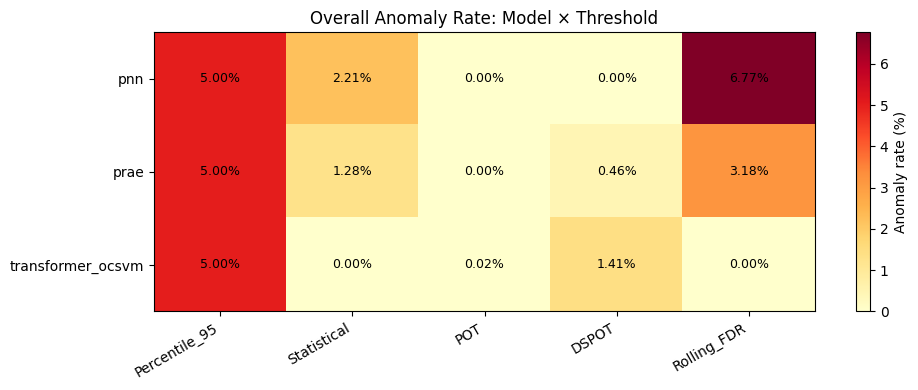

In [5]:
# Pivot: overall anomaly rate per model x threshold
overall = results_df[results_df["Period"] == "ALL"].pivot_table(
    index="Model", columns="Threshold", values="Rate_pct", aggfunc="first")
overall = overall[list(THRESHOLD_CONFIGS.keys())]

print("Overall anomaly rate (%) by model and threshold:")
display(overall)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(overall.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(overall.columns)))
ax.set_xticklabels(overall.columns, rotation=30, ha="right")
ax.set_yticks(range(len(overall.index)))
ax.set_yticklabels(overall.index)
for i in range(len(overall.index)):
    for j in range(len(overall.columns)):
        ax.text(j, i, f"{overall.values[i, j]:.2f}%", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Anomaly rate (%)")
ax.set_title("Overall Anomaly Rate: Model × Threshold")
plt.tight_layout()
plt.show()

## Per-Period Breakdown

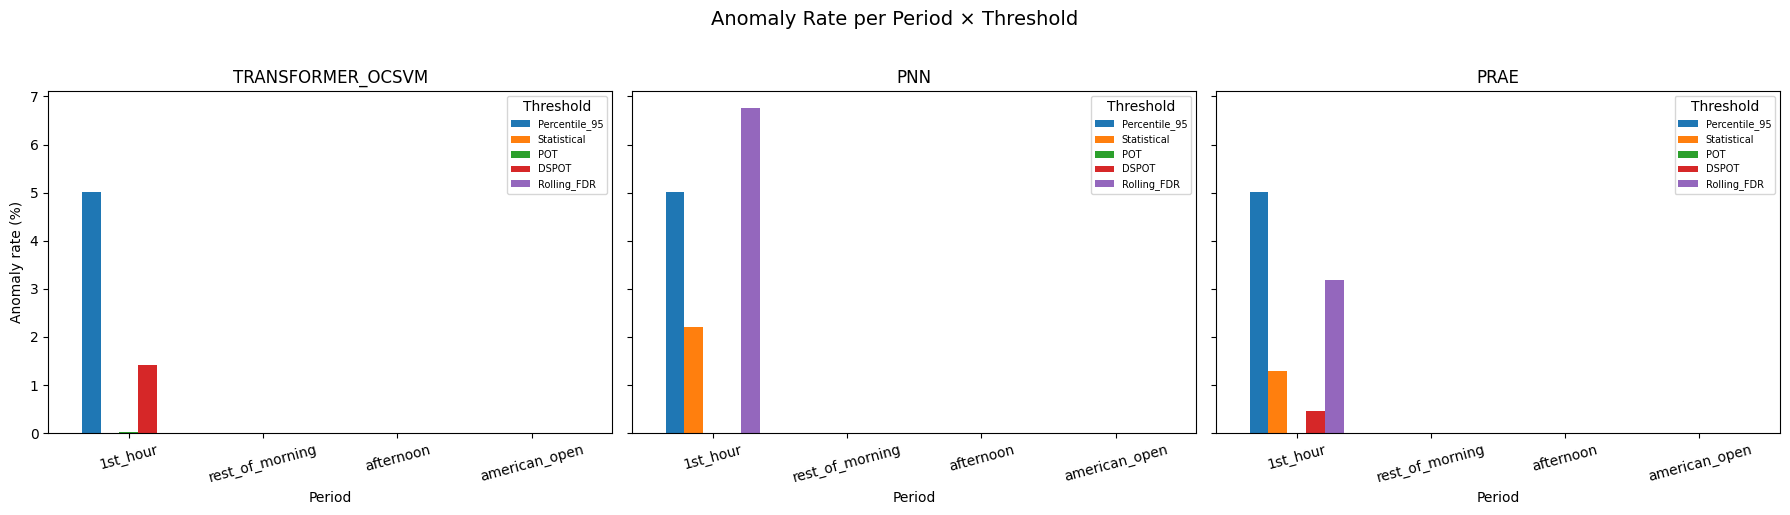


TRANSFORMER_OCSVM


Threshold,Percentile_95,Statistical,POT,DSPOT,Rolling_FDR
Period,,,,,
1st_hour,5.003,0.0,0.02,1.414,0.0
rest_of_morning,NaN,NaN,NaN,NaN,NaN
afternoon,NaN,NaN,NaN,NaN,NaN
american_open,NaN,NaN,NaN,NaN,NaN



PNN


Threshold,Percentile_95,Statistical,POT,DSPOT,Rolling_FDR
Period,,,,,
1st_hour,5.003,2.206,0.0,0.0,6.767
rest_of_morning,NaN,NaN,NaN,NaN,NaN
afternoon,NaN,NaN,NaN,NaN,NaN
american_open,NaN,NaN,NaN,NaN,NaN



PRAE


Threshold,Percentile_95,Statistical,POT,DSPOT,Rolling_FDR
Period,,,,,
1st_hour,5.003,1.283,0.0,0.461,3.178
rest_of_morning,NaN,NaN,NaN,NaN,NaN
afternoon,NaN,NaN,NaN,NaN,NaN
american_open,NaN,NaN,NaN,NaN,NaN


In [6]:
# One grouped bar chart per model, showing anomaly rate by period for each threshold
period_order = list(PERIODS.keys())

fig, axes = plt.subplots(1, len(MODEL_TYPES), figsize=(6 * len(MODEL_TYPES), 5), sharey=True)
if len(MODEL_TYPES) == 1:
    axes = [axes]

for ax, mt in zip(axes, MODEL_TYPES):
    sub = results_df[(results_df["Model"] == mt) & (results_df["Period"] != "ALL")]
    pivot = sub.pivot_table(index="Period", columns="Threshold", values="Rate_pct", aggfunc="first")
    pivot = pivot.reindex(period_order)
    pivot = pivot[list(THRESHOLD_CONFIGS.keys())]
    pivot.plot(kind="bar", ax=ax, rot=15, width=0.7)
    ax.set_title(mt.upper())
    ax.set_ylabel("Anomaly rate (%)")
    ax.legend(fontsize=7, title="Threshold")

plt.suptitle("Anomaly Rate per Period × Threshold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Detailed table
for mt in MODEL_TYPES:
    print(f"\n{'='*70}")
    print(f"{mt.upper()}")
    sub = results_df[(results_df["Model"] == mt) & (results_df["Period"] != "ALL")]
    pivot = sub.pivot_table(index="Period", columns="Threshold", values="Rate_pct", aggfunc="first")
    pivot = pivot.reindex(period_order)[list(THRESHOLD_CONFIGS.keys())]
    display(pivot)

## Score Distributions & Threshold Positions

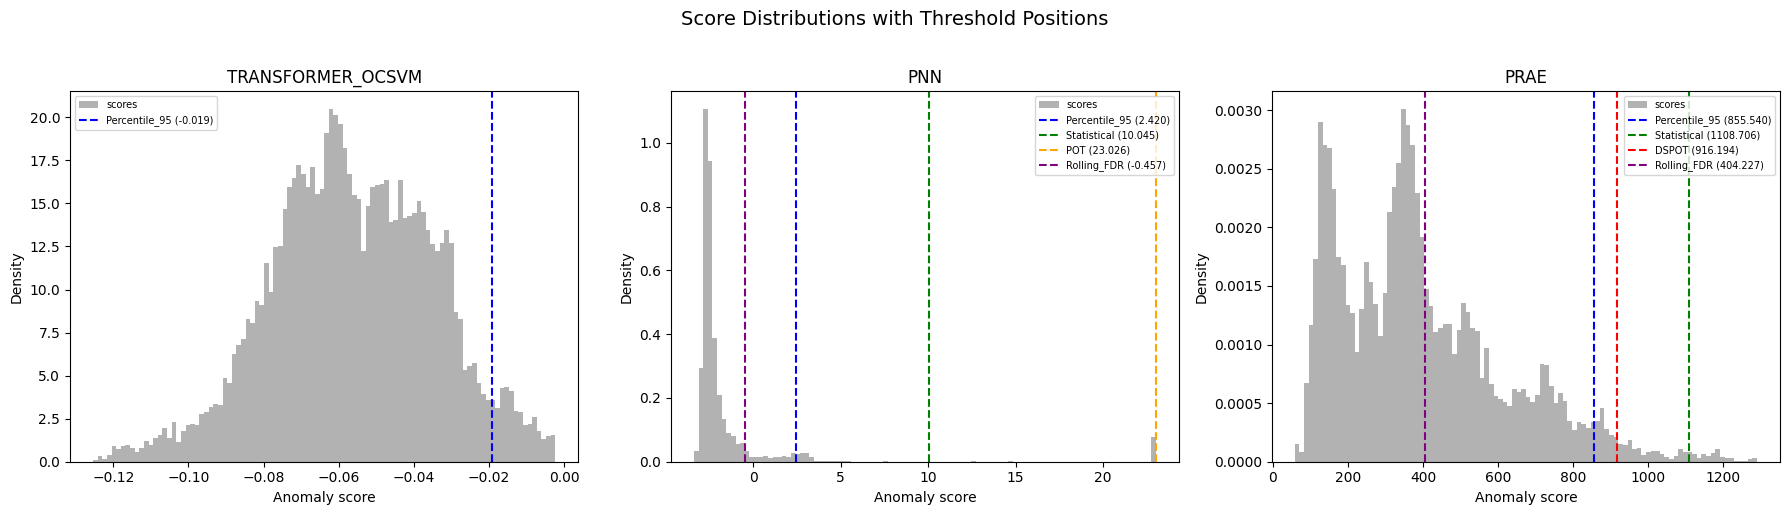


Threshold analysis complete.


In [7]:
# Histogram of scores with threshold lines overlaid
fig, axes = plt.subplots(1, len(MODEL_TYPES), figsize=(6 * len(MODEL_TYPES), 5))
if len(MODEL_TYPES) == 1:
    axes = [axes]

thresh_colors = {"Percentile_95": "blue", "Statistical": "green",
                 "POT": "orange", "DSPOT": "red", "Rolling_FDR": "purple"}

for ax, mt in zip(axes, MODEL_TYPES):
    scores = all_scores[mt]
    # Clip for display (remove extreme outliers in histogram)
    q99 = np.percentile(scores, 99.5)
    ax.hist(scores[scores <= q99], bins=100, alpha=0.6, color="grey", density=True, label="scores")

    for thresh_name, thresh_cfg in THRESHOLD_CONFIGS.items():
        sub = results_df[(results_df["Model"] == mt) & 
                         (results_df["Threshold"] == thresh_name) & 
                         (results_df["Period"] == "ALL")]
        if len(sub) > 0:
            t_val = sub.iloc[0]["Threshold_value"]
            if not np.isnan(t_val) and t_val <= q99 * 1.5:
                ax.axvline(t_val, color=thresh_colors.get(thresh_name, "black"),
                          linestyle="--", linewidth=1.5, label=f"{thresh_name} ({t_val:.3f})")

    ax.set_title(mt.upper())
    ax.set_xlabel("Anomaly score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.suptitle("Score Distributions with Threshold Positions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nThreshold analysis complete.")